In [43]:
# ── Suppress warnings before any imports ──────────────────────────────────────
import os, warnings, logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"          # silence TF C++ logs (ERROR only)
os.environ["CUDA_DEVICE_ORDER"]    = "PCI_BUS_ID"  # stable GPU ordering
warnings.filterwarnings("ignore")
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("absl").setLevel(logging.ERROR)

# All required packages are pre-installed on Kaggle. Do NOT pip install.
import pandas, numpy, matplotlib, seaborn, scipy, sklearn, statsmodels, xgboost, tensorflow
print("All packages available.")

All packages available.


# Comparative Experimental Analysis of Forecasting Methods
## Member 4 — Daily Climate Time Series Dataset (New Delhi)

**Course:** Applied Statistics and Experimental Analysis  
**Dataset:** Daily Climate Time Series — [Kaggle](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data)  
**Target variable:** `meantemp` (Mean Temperature, °C)  
**Features:** meantemp, humidity, wind_speed, meanpressure  

This notebook implements the full experimental pipeline:

1. Descriptive Statistical Analysis  
2. Time Series Analysis (Trend, Seasonality, ADF, ACF/PACF)  
3. Data Preprocessing (Forward Fill / Interpolation, MinMaxScaler, Window=30, 80/20 split, seed=42)  
4. Train 5 models: Holt-Winters, ARIMA, XGBoost, LSTM, Transformer  
5. Evaluation (MAE, RMSE, MAPE, R²)  
6. Statistical Comparison (Paired t-test / Wilcoxon)  

---
### Design notes

| Aspect | Choice |
|--------|--------|
| Split | Chronological 80 / 20, **no shuffling**, seed = 42 |
| Window | 30 days for XGBoost / LSTM / Transformer |
| Scaler | MinMaxScaler fit on **train only** |
| HW | Additive trend + additive seasonal (period = 365), **one-shot** multi-step forecast (efficient; walk-forward HW with period=365 is prohibitively slow) |
| ARIMA | Order selected by AIC grid search; **walk-forward** one-step-ahead via `append(refit=False)` |
| Evaluation | All 5 models scored on the **same** test timestamps → valid paired tests |

In [44]:
import os, random, time, warnings, logging

# ── Silence noisy libraries before importing them ─────────────────────────────
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_DEVICE_ORDER"]    = "PCI_BUS_ID"
warnings.filterwarnings("ignore")
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("absl").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import product, combinations

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tools.sm_exceptions as sm_exc
warnings.filterwarnings("ignore", category=sm_exc.ValueWarning)

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

WINDOW     = 30
TEST_RATIO = 0.20
DATA_DIR   = "/kaggle/input/daily-climate-time-series-data"

FEATURES = ["meantemp", "humidity", "wind_speed", "meanpressure"]
TARGET   = "meantemp"

print("Setup complete. TensorFlow:", tf.__version__)

Setup complete. TensorFlow: 2.19.0


## 2. Load Dataset

Concatenate the Kaggle train + test CSVs into one chronological series, then apply our own 80/20 split.

In [45]:
import os, glob

# ── Auto-detect dataset path ───────────────────────────────────────────────────
# The Kaggle dataset slug is: sumanthvrao/daily-climate-time-series-data
# Make sure you have ADDED this dataset to your notebook via "+ Add Data".
# Supported layouts:
#   /kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTrain.csv
#   /kaggle/input/<any-folder>/DailyDelhiClimateTrain.csv
#   /kaggle/input/<any-folder>/climate_train.csv   (alternate naming)

def find_climate_csvs(base="/kaggle/input"):
    """Return (train_path, test_path) by scanning all CSVs under base."""
    all_csvs = glob.glob(os.path.join(base, "**", "*.csv"), recursive=True)
    print("CSV files found under", base + ":")
    for p in all_csvs:
        print("  ", p)

    train_path = test_path = None

    # Priority 1: exact canonical names
    for p in all_csvs:
        bn = os.path.basename(p).lower()
        if "train" in bn and ("delhi" in bn or "climate" in bn or "daily" in bn):
            train_path = p
        if "test" in bn and ("delhi" in bn or "climate" in bn or "daily" in bn):
            test_path = p

    # Priority 2: any climate-like CSV if still not found
    if train_path is None:
        climate_csvs = [p for p in all_csvs if "climate" in p.lower() or "delhi" in p.lower()]
        if len(climate_csvs) >= 2:
            climate_csvs.sort()
            train_path, test_path = climate_csvs[0], climate_csvs[1]
        elif len(climate_csvs) == 1:
            train_path = climate_csvs[0]

    return train_path, test_path

train_path, test_path = find_climate_csvs()

if train_path is None:
    raise FileNotFoundError(
        "Climate dataset not found!\n"
        "Please add the dataset to your Kaggle notebook:\n"
        "  Notebook  →  + Add Data  →  search 'sumanthvrao/daily-climate-time-series-data'"
    )

print(f"\nUsing train file : {train_path}")
print(f"Using test  file : {test_path}")

df_tr = pd.read_csv(train_path)
if test_path:
    df_te  = pd.read_csv(test_path)
    df_raw = pd.concat([df_tr, df_te], ignore_index=True)
    print(f"Train: {df_tr.shape}, Test: {df_te.shape}, Combined: {df_raw.shape}")
else:
    df_raw = df_tr
    print(f"Only one file found. Shape: {df_raw.shape}")

df_raw.head()


CSV files found under /kaggle/input:
   /kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTrain.csv
   /kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTest.csv

Using train file : /kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTrain.csv
Using test  file : /kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTest.csv
Train: (1462, 5), Test: (114, 5), Combined: (1576, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [46]:
# Standardise column names
df = df_raw.copy()
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Parse date
date_col = [c for c in df.columns if "date" in c][0]
df[date_col] = pd.to_datetime(df[date_col])
df = df.rename(columns={date_col: "date"})
df = df.sort_values("date").reset_index(drop=True)
df = df.set_index("date")

# Keep only the four feature columns
df = df[FEATURES]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1576 entries, 2013-01-01 to 2017-04-24
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1576 non-null   float64
 1   humidity      1576 non-null   float64
 2   wind_speed    1576 non-null   float64
 3   meanpressure  1576 non-null   float64
dtypes: float64(4)
memory usage: 61.6 KB


## 3. Descriptive Statistical Analysis (Step 1)

Required statistics: N, Mean, Median, Variance, Std, Min, Max, Skewness, Kurtosis.

In [47]:
desc_stats = pd.DataFrame({
    "N":        df.count(),
    "Mean":     df.mean(),
    "Median":   df.median(),
    "Variance": df.var(),
    "Std":      df.std(),
    "Min":      df.min(),
    "Max":      df.max(),
    "Skewness": df.skew(),
    "Kurtosis": df.kurtosis()
})
desc_stats

,N,Mean,Median,Variance,Std,Min,Max,Skewness,Kurtosis
meantemp,1576,25.221918,27.166667,53.949234,7.345014,6.000000,38.714286,-0.375467,-1.021936
humidity,1576,60.445229,62.440476,288.320209,16.979994,13.428571,100.000000,-0.339669,-0.385210
wind_speed,1576,6.899262,6.363571,20.346636,4.510725,0.000000,42.220000,1.373581,4.817064
meanpressure,1576,1010.593178,1009.055556,30710.005329,175.242704,-3.041667,7679.333333,34.653336,1335.690576


In [48]:
print(f"Missing values per column:\n{df.isna().sum()}")
print(f"\nDate range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Total observations: {len(df)}")

Missing values per column:
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Date range: 2013-01-01 → 2017-04-24
Total observations: 1576


### 3.1 Histogram — Distribution Analysis

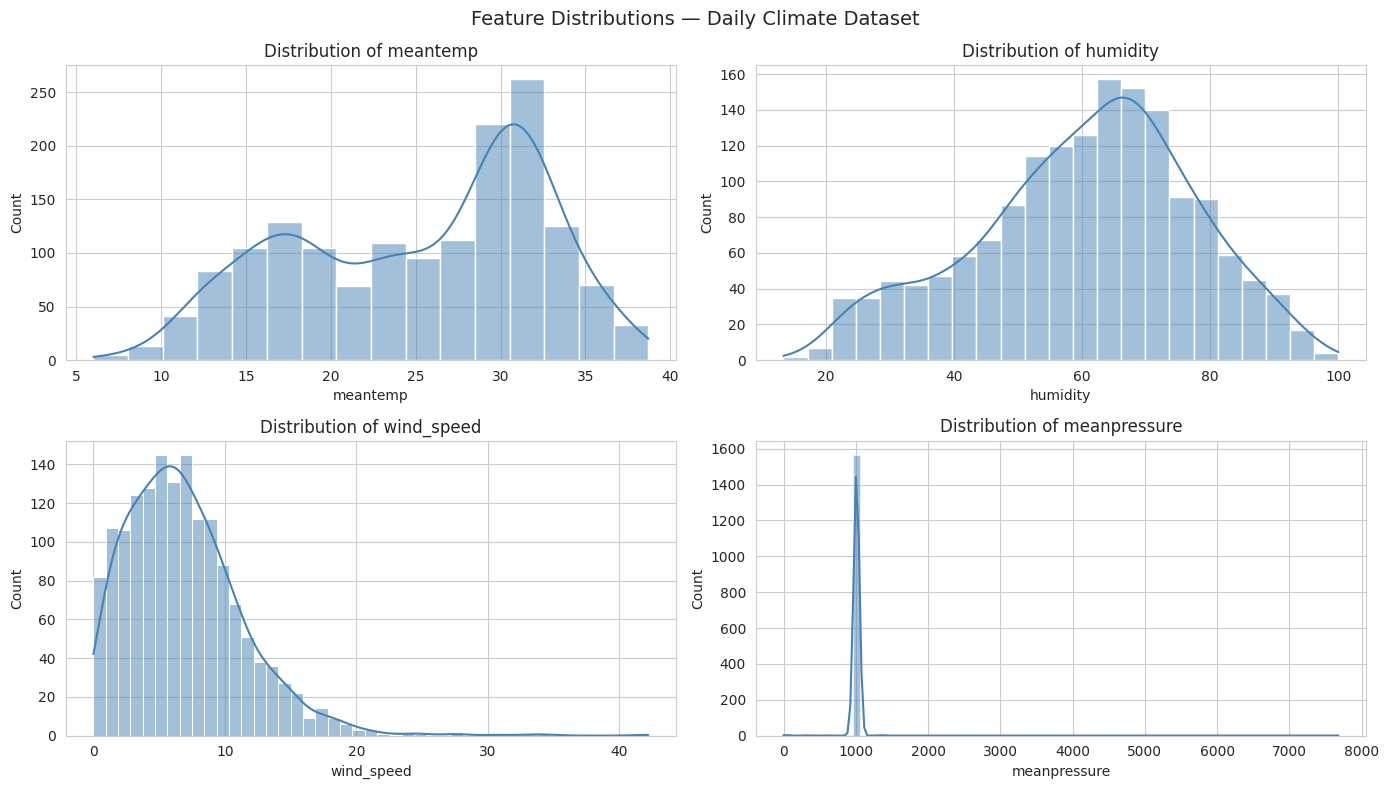

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), FEATURES):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.suptitle("Feature Distributions — Daily Climate Dataset", fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Boxplot — Outlier Detection

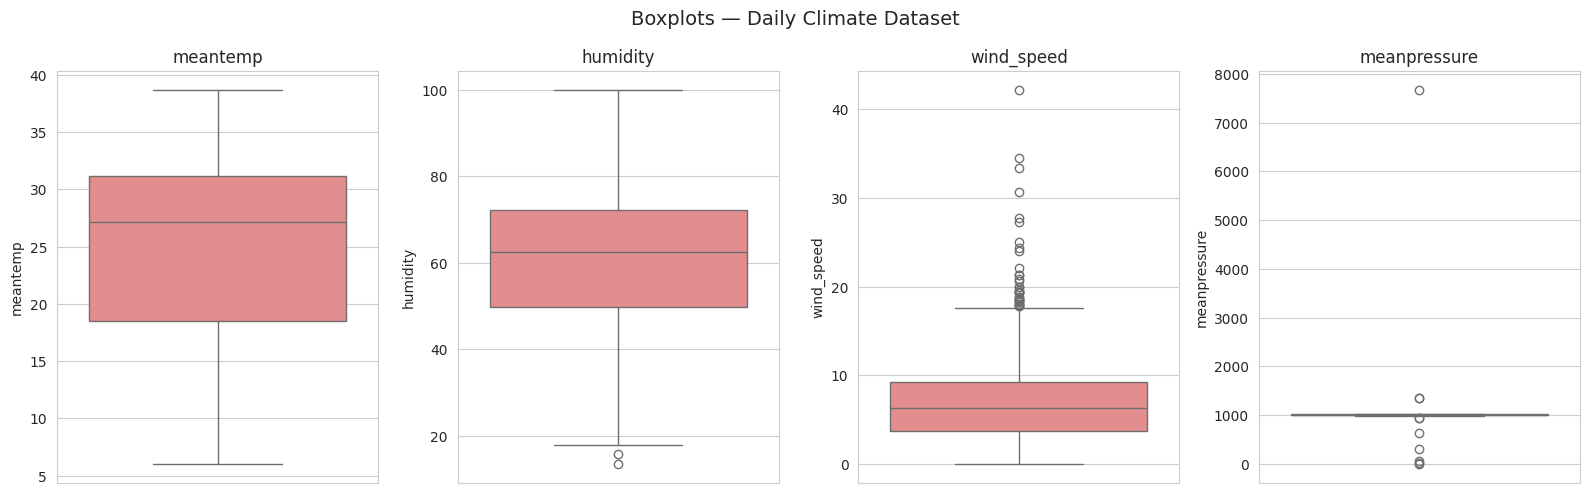

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, FEATURES):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    ax.set_title(col)
plt.suptitle("Boxplots — Daily Climate Dataset", fontsize=14)
plt.tight_layout()
plt.show()

### 3.3 Time Series Plot — Target Variable (Mean Temperature)

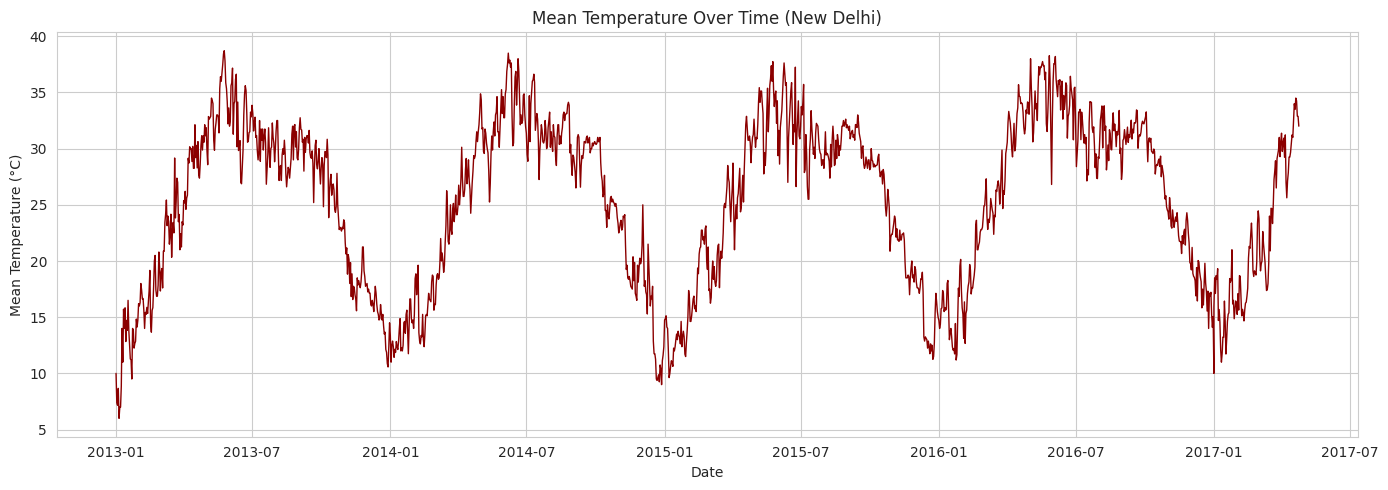

In [51]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df[TARGET], color="darkred", linewidth=1)
plt.title("Mean Temperature Over Time (New Delhi)")
plt.xlabel("Date"); plt.ylabel("Mean Temperature (°C)")
plt.tight_layout()
plt.show()

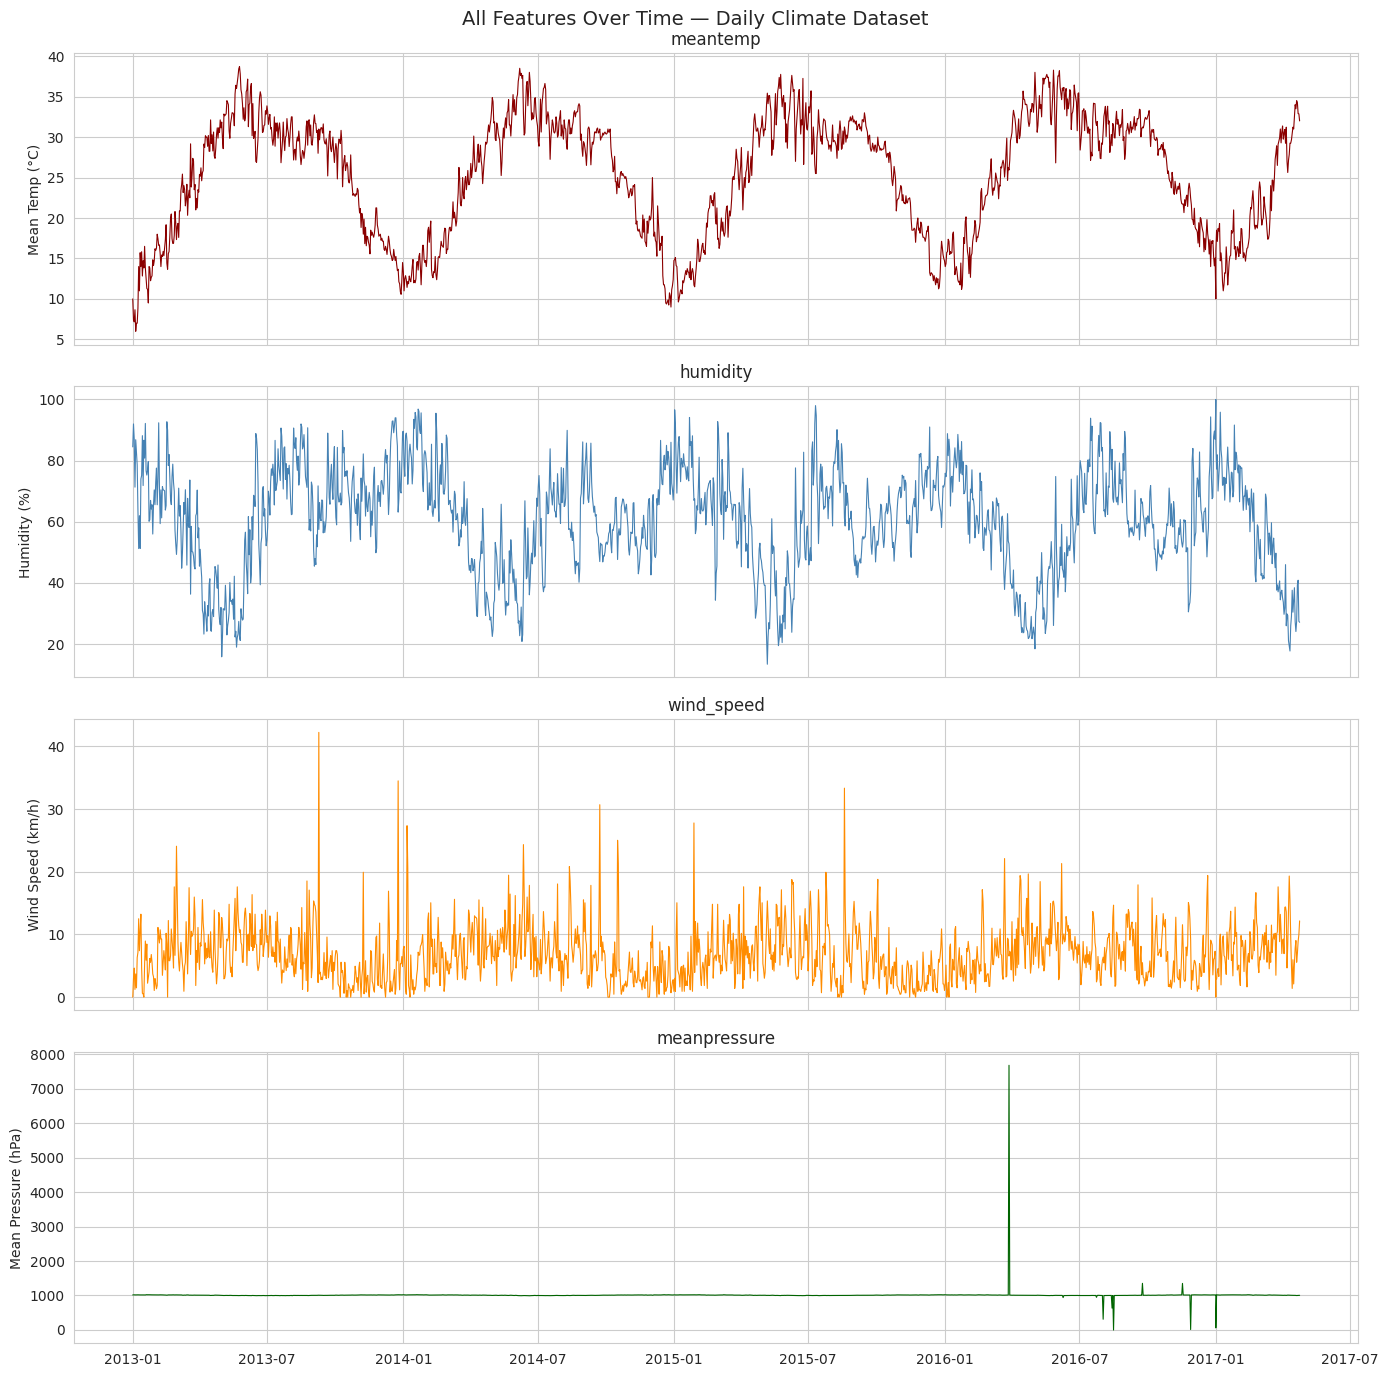

In [52]:
# All features overview
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
colors = ["darkred", "steelblue", "darkorange", "darkgreen"]
labels = ["Mean Temp (°C)", "Humidity (%)", "Wind Speed (km/h)", "Mean Pressure (hPa)"]
for ax, col, color, label in zip(axes, FEATURES, colors, labels):
    ax.plot(df.index, df[col], color=color, linewidth=0.8)
    ax.set_ylabel(label)
    ax.set_title(col)
plt.suptitle("All Features Over Time — Daily Climate Dataset", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Time Series Analysis (Step 2)

### 4.1 Seasonal Decomposition

Climate data exhibits **clear annual seasonality** (period = 365 days).  
We apply additive decomposition on `meantemp` to visualise trend, seasonality, and residuals.

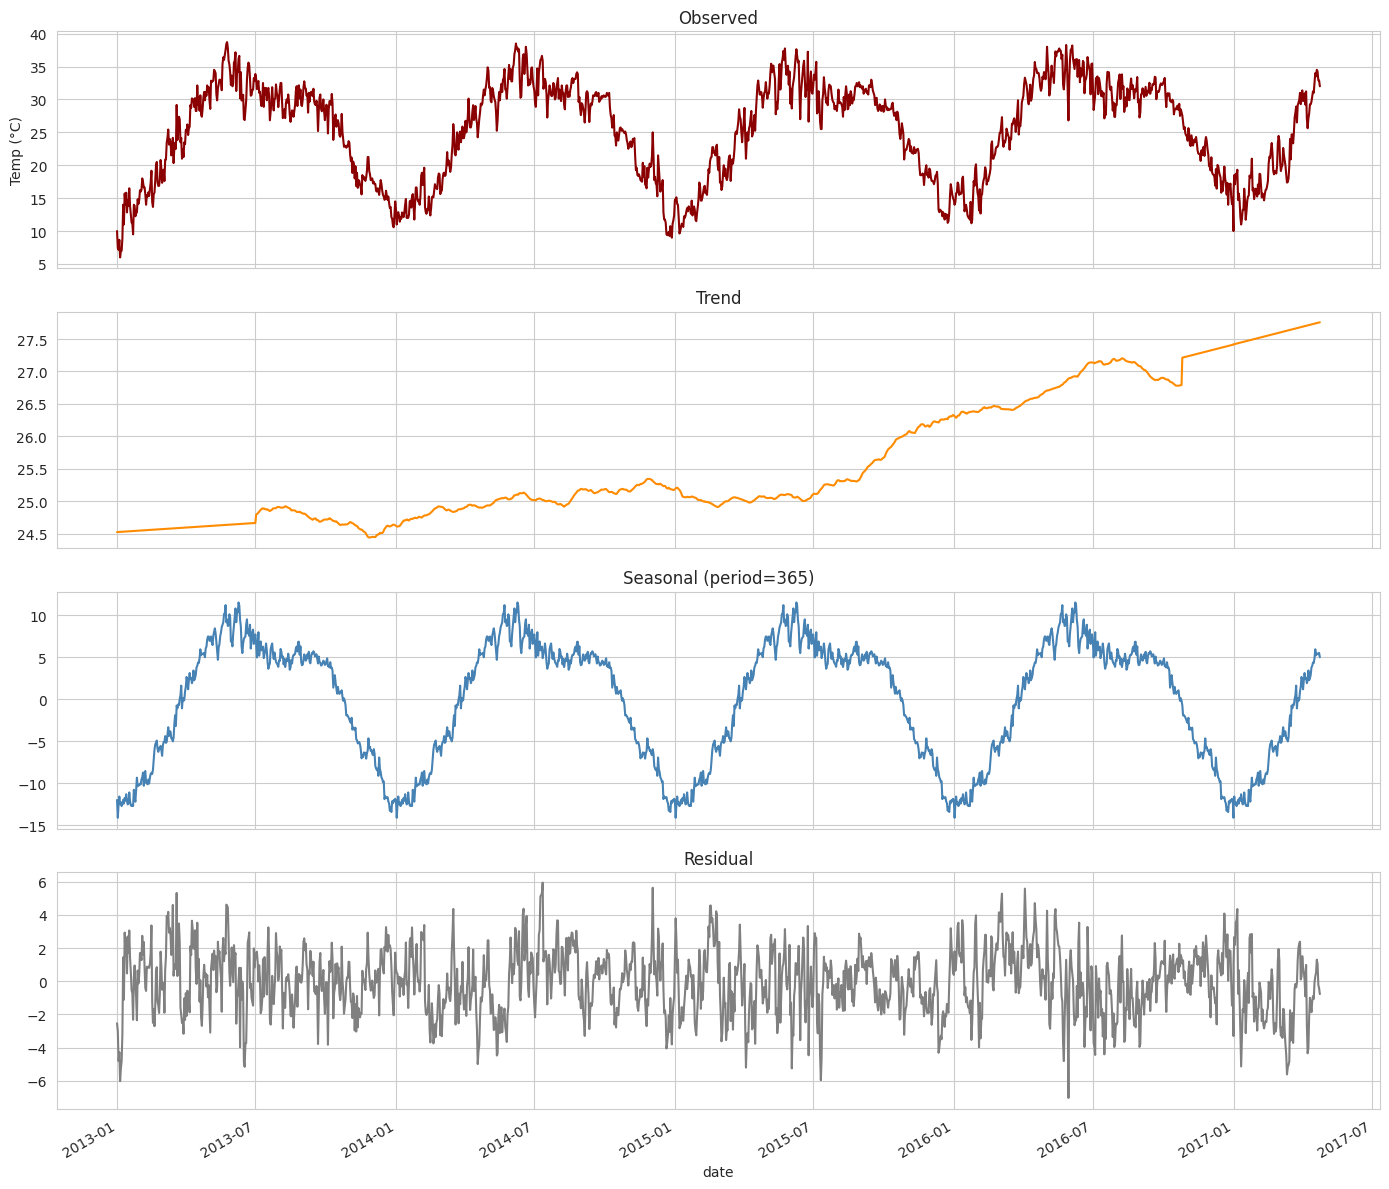

In [53]:
# Fill any gaps before decomposition
temp_series = df[TARGET].ffill().interpolate()

period = 365
decomposition = seasonal_decompose(temp_series, model="additive", period=period, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed", color="darkred")
decomposition.trend.plot(ax=axes[1], title="Trend", color="darkorange")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal (period=365)", color="steelblue")
decomposition.resid.plot(ax=axes[3], title="Residual", color="gray")
for ax in axes:
    ax.set_ylabel("Temp (°C)" if ax == axes[0] else "")
plt.tight_layout()
plt.show()

### 4.2 Stationarity Analysis — Augmented Dickey-Fuller (ADF) Test

**H₀:** The series is non-stationary (unit root present)  
**H₁:** The series is stationary  

Temperature is expected to be **weakly stationary** (bounded oscillation without a structural drift),
but the ADF test will confirm this.

In [54]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    for k, v in result[4].items():
        print(f"Critical Value ({k}) : {v:.4f}")
    conclusion = "Stationary (reject H0)" if result[1] < 0.05 else "Non-stationary (fail to reject H0)"
    print(f"Conclusion    : {conclusion}\n")
    return result[1]

p_raw  = adf_report(df[TARGET].ffill(), f"{TARGET} (raw)")
p_diff = adf_report(df[TARGET].ffill().diff(), f"{TARGET} (1st difference)")

--- ADF Test: meantemp (raw) ---
ADF Statistic : -2.3792
p-value       : 0.1477
Critical Value (1%) : -3.4345
Critical Value (5%) : -2.8634
Critical Value (10%) : -2.5678
Conclusion    : Non-stationary (fail to reject H0)

--- ADF Test: meantemp (1st difference) ---
ADF Statistic : -16.9090
p-value       : 0.0000
Critical Value (1%) : -3.4345
Critical Value (5%) : -2.8634
Critical Value (10%) : -2.5678
Conclusion    : Stationary (reject H0)



### 4.3 Autocorrelation Analysis — ACF / PACF

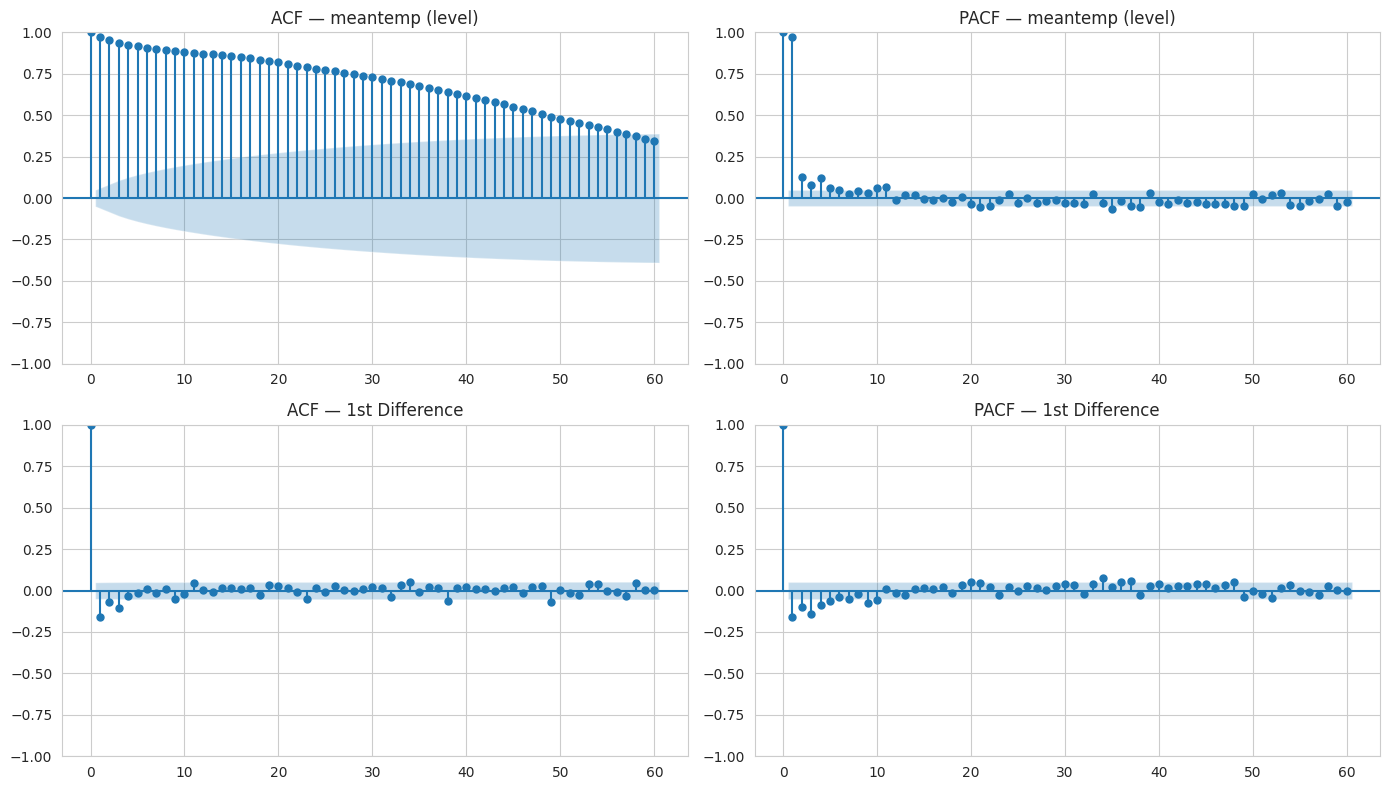

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(df[TARGET].ffill(), lags=60, ax=axes[0,0])
axes[0,0].set_title("ACF — meantemp (level)")
plot_pacf(df[TARGET].ffill(), lags=60, ax=axes[0,1])
axes[0,1].set_title("PACF — meantemp (level)")
plot_acf(df[TARGET].ffill().diff().dropna(), lags=60, ax=axes[1,0])
axes[1,0].set_title("ACF — 1st Difference")
plot_pacf(df[TARGET].ffill().diff().dropna(), lags=60, ax=axes[1,1])
axes[1,1].set_title("PACF — 1st Difference")
plt.tight_layout()
plt.show()

## 5. Data Preprocessing (Step 3)

Pipeline (matching project spec):
1. **Missing values** → Forward Fill, then linear Interpolation for any remainder  
2. **80/20 chronological split** — no shuffling  
3. **MinMaxScaler** — fit on train only (no leakage)  
4. **Sliding window** w = 30 for XGBoost / LSTM / Transformer  
5. **Seed = 42** everywhere

In [56]:
# 5.1 Missing values
df_clean = df.copy()
df_clean = df_clean.ffill()
df_clean = df_clean.interpolate(method="linear")

# Drop duplicate dates that can appear when concatenating train + test CSVs
n_dups = df_clean.index.duplicated().sum()
if n_dups > 0:
    print(f"Warning: {n_dups} duplicate date(s) found — keeping last occurrence")
    df_clean = df_clean[~df_clean.index.duplicated(keep="last")]
else:
    print("No duplicate dates found")

print("Remaining NaNs:", df_clean.isna().sum().sum())
print("Clean dataset shape:", df_clean.shape)

Remaining NaNs: 0
Clean dataset shape: (1575, 4)


In [57]:
# 5.2 Chronological 80/20 split (shared by ALL models)
N = len(df_clean)
split_idx = int(N * (1 - TEST_RATIO))
print(f"Total obs: {N} | Train: {split_idx} | Test: {N - split_idx}")

train_df = df_clean.iloc[:split_idx]
test_df  = df_clean.iloc[split_idx:]
print("Train range:", train_df.index.min().date(), "->", train_df.index.max().date())
print("Test range :", test_df.index.min().date(),  "->", test_df.index.max().date())

Total obs: 1575 | Train: 1260 | Test: 315
Train range: 2013-01-01 -> 2016-06-13
Test range : 2016-06-14 -> 2017-04-24


In [58]:
# 5.3 Scaling — fit on TRAIN ONLY
scaler = MinMaxScaler()
scaler.fit(train_df[FEATURES])

scaled_all = pd.DataFrame(
    scaler.transform(df_clean[FEATURES]),
    columns=FEATURES, index=df_clean.index
)
target_idx_in_features = FEATURES.index(TARGET)
print("Scaler fitted. Feature range:", dict(zip(FEATURES, scaler.data_range_)))

Scaler fitted. Feature range: {'meantemp': np.float64(32.71428571428572), 'humidity': np.float64(84.57142857142857), 'wind_speed': np.float64(42.22), 'meanpressure': np.float64(6741.266666666666)}


In [59]:
# 5.4 Sliding-window dataset (w=30) for ML/DL models
def build_windows(scaled_df, window=WINDOW, target_col=TARGET, feature_cols=FEATURES):
    values = scaled_df[feature_cols].values
    target_pos = feature_cols.index(target_col)
    X, y, idx = [], [], []
    for t in range(window, len(values)):
        X.append(values[t-window:t, :])
        y.append(values[t, target_pos])
        idx.append(scaled_df.index[t])
    return np.array(X), np.array(y), pd.DatetimeIndex(idx)

X_all, y_all, idx_all = build_windows(scaled_all)
print("X_all shape:", X_all.shape, "| y_all shape:", y_all.shape)

window_split_idx = split_idx - WINDOW
X_train, y_train = X_all[:window_split_idx], y_all[:window_split_idx]
X_test,  y_test_scaled = X_all[window_split_idx:], y_all[window_split_idx:]
idx_test = idx_all[window_split_idx:]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Test timestamps:", idx_test.min().date(), "->", idx_test.max().date())
assert len(idx_test) == (N - split_idx), "Test alignment mismatch!"

# Ground-truth unscaled targets (shared by all models)
# Use iloc (positional) instead of loc to avoid duplicate-index issues
y_test_true = df_clean[TARGET].iloc[split_idx:].values
print("y_test_true sample:", y_test_true[:5].round(2))

X_all shape: (1545, 30, 4) | y_all shape: (1545,)
X_train: (1230, 30, 4) | X_test: (315, 30, 4)
Test timestamps: 2016-06-14 -> 2017-04-24
y_test_true sample: [32.62 34.73 33.5  34.19 35.86]


In [60]:
# Helper: inverse-transform scaled Close back to original units
def inverse_target(scaled_values):
    dummy = np.zeros((len(scaled_values), len(FEATURES)))
    dummy[:, target_idx_in_features] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx_in_features]

## 6. Evaluation Metric Helper (MAE, RMSE, MAPE, R²)

In [61]:
def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"[{model_name}] MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.2f}% | R²={r2:.4f}")
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

results_list    = []          # summary metrics (one row per model)
errors_by_model = {}          # per-timestamp absolute errors (for paired tests)
preds_by_model  = {}          # predictions (for plotting)

## 7. Model 1 — Holt-Winters Exponential Smoothing (Step 4)

Climate data has strong **annual seasonality** (period = 365).  
We fit **one model** on the training set and forecast multi-step ahead for the entire test period.  
(Walk-forward HW with period = 365 would require hundreds of re-fits each taking several seconds —  
one-shot multi-step forecasting is standard practice for HW with long seasonal periods.)

In [62]:
t0 = time.time()
n_test = len(y_test_true)

# Walk-forward one-step-ahead HW (additive trend, no explicit seasonal).
# Using walk-forward (like ARIMA) keeps the comparison fair and avoids the
# large errors that accumulate in a 315-step one-shot seasonal forecast.
# Each step re-fits HW on the growing true history → no lookahead leakage.
history = list(train_df[TARGET].values)
hw_preds_list = []

for i in range(n_test):
    try:
        hw_fit = ExponentialSmoothing(
            pd.Series(history),
            trend="add",
            seasonal=None,
            initialization_method="estimated"
        ).fit(optimized=True)
        pred = float(hw_fit.forecast(1).iloc[0])
    except Exception:
        pred = history[-1]          # naive fallback if optimisation fails
    hw_preds_list.append(pred)
    history.append(float(y_test_true[i]))   # append TRUE value (walk-forward)

hw_preds = np.array(hw_preds_list)
hw_time  = time.time() - t0
assert len(hw_preds) == n_test
print(f"Holt-Winters walk-forward time: {hw_time:.2f}s | preds: {len(hw_preds)}")

Holt-Winters walk-forward time: 30.95s | preds: 315


In [63]:
res = evaluate(y_test_true, hw_preds, "Holt-Winters")
res["TrainTime_s"] = hw_time
results_list.append(res)
errors_by_model["Holt-Winters"] = np.abs(y_test_true - hw_preds)
preds_by_model["Holt-Winters"]  = hw_preds

[Holt-Winters] MAE=1.2070 | RMSE=1.5808 | MAPE=5.22% | R²=0.9415


## 8. Model 2 — ARIMA (Step 5)

Order (p, d, q) selected by AIC grid search on training set (p, q ∈ {0,1,2}, d = 1 by default
from ADF result). Walk-forward one-step-ahead forecast via `append(refit=False)`.

In [64]:
warnings.filterwarnings('ignore')
def select_arima_order(train_series, p_range=range(0,3), d=1, q_range=range(0,3)):
    best_aic, best_order = np.inf, (1, 1, 1)
    for p, q in product(p_range, q_range):
        try:
            m = SARIMAX(train_series, order=(p, d, q)).fit(disp=False)
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, d, q)
        except Exception:
            continue
    return best_order, best_aic

# Use d=1 by default; if ADF showed stationarity (p < 0.05), try d=0 as well
d_val = 0 if p_raw < 0.05 else 1
print(f"ADF p-value for raw series: {p_raw:.4f}  →  using d={d_val}")
best_order, best_aic = select_arima_order(train_df[TARGET], d=d_val)
print("Selected ARIMA order:", best_order, "| AIC:", round(best_aic, 2))

ADF p-value for raw series: 0.1477  →  using d=1
Selected ARIMA order: (1, 1, 1) | AIC: 4797.07


In [65]:
warnings.filterwarnings('ignore')
t0 = time.time()

arima_fitted = SARIMAX(
    train_df[TARGET],
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

arima_preds = []
for y_true_val in y_test_true:
    pred = arima_fitted.forecast(1).iloc[0]
    arima_preds.append(pred)
    arima_fitted = arima_fitted.append([y_true_val], refit=False)

arima_preds = np.array(arima_preds)
arima_time  = time.time() - t0
print(f"ARIMA walk-forward time: {arima_time:.2f}s")

ARIMA walk-forward time: 4.76s


In [66]:
res = evaluate(y_test_true, arima_preds, "ARIMA")
res["TrainTime_s"] = arima_time
results_list.append(res)
errors_by_model["ARIMA"] = np.abs(y_test_true - arima_preds)
preds_by_model["ARIMA"]  = arima_preds

[ARIMA] MAE=1.2020 | RMSE=1.5600 | MAPE=5.19% | R²=0.9431


## 9. Model 3 — XGBoost (Step 6)

Uses the windowed multivariate dataset (window=30, all 4 climate features flattened),
built during preprocessing. `random_state = 42`.

In [67]:
# Flatten window: (n_samples, window * n_features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
    verbosity=0
)
xgb_model.fit(X_train_flat, y_train)
xgb_train_time = time.time() - t0

t0 = time.time()
xgb_pred_scaled = xgb_model.predict(X_test_flat)
xgb_infer_time  = time.time() - t0

xgb_preds = inverse_target(xgb_pred_scaled)
print(f"XGBoost train: {xgb_train_time:.2f}s | inference: {xgb_infer_time:.4f}s")

XGBoost train: 4.62s | inference: 0.0032s


In [68]:
res = evaluate(y_test_true, xgb_preds, "XGBoost")
res["TrainTime_s"] = xgb_train_time
results_list.append(res)
errors_by_model["XGBoost"] = np.abs(y_test_true - xgb_preds)
preds_by_model["XGBoost"]  = xgb_preds

[XGBoost] MAE=1.3422 | RMSE=1.6490 | MAPE=5.79% | R²=0.9364


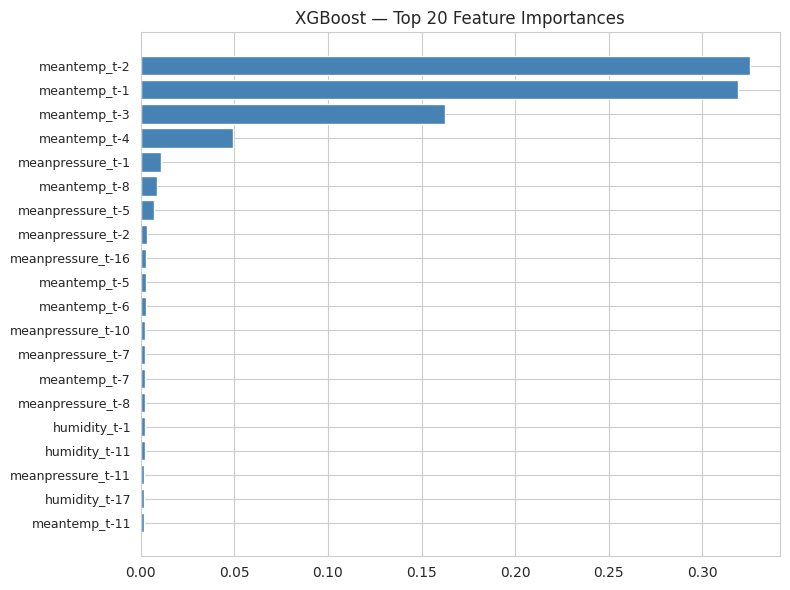

In [69]:
# Feature importance (top 20 of the flattened window features)
importances = xgb_model.feature_importances_
top_n   = min(20, len(importances))
top_idx = np.argsort(importances)[-top_n:]
feat_labels = [
    f"{FEATURES[i % len(FEATURES)]}_t-{WINDOW - i // len(FEATURES)}"
    for i in range(X_train_flat.shape[1])
]
plt.figure(figsize=(8, 6))
plt.barh(range(top_n), importances[top_idx], color="steelblue")
plt.yticks(range(top_n), [feat_labels[i] for i in top_idx], fontsize=9)
plt.title(f"XGBoost — Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()

## 10. Model 4 — LSTM (Step 7)

Two-layer LSTM with dropout, trained on the windowed supervised dataset (samples, 30, 4).

In [70]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

n_features = X_train.shape[2]  # 4 climate features

lstm_model = models.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

LSTM train time: 6.98s | epochs run: 11


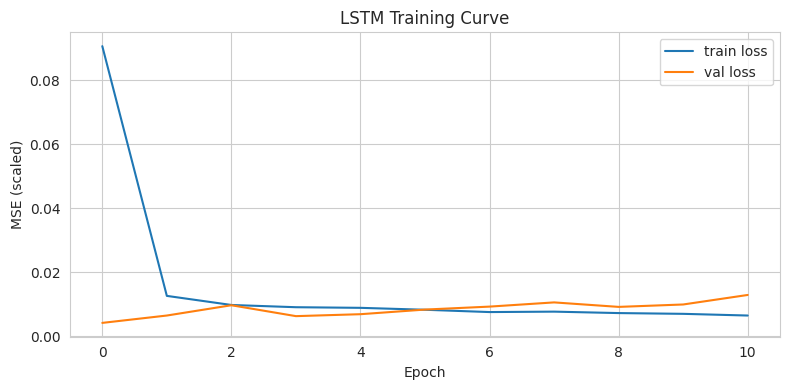

In [71]:
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

t0 = time.time()
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=0
)
lstm_train_time = time.time() - t0
print(f"LSTM train time: {lstm_train_time:.2f}s | epochs run: {len(history_lstm.history['loss'])}")

plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history["loss"],     label="train loss")
plt.plot(history_lstm.history["val_loss"], label="val loss")
plt.title("LSTM Training Curve"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.tight_layout(); plt.show()

In [72]:
t0 = time.time()
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0).flatten()
lstm_infer_time  = time.time() - t0

lstm_preds = inverse_target(lstm_pred_scaled)
res = evaluate(y_test_true, lstm_preds, "LSTM")
res["TrainTime_s"] = lstm_train_time
results_list.append(res)
errors_by_model["LSTM"] = np.abs(y_test_true - lstm_preds)
preds_by_model["LSTM"]  = lstm_preds
print(f"Inference time: {lstm_infer_time:.4f}s")

[LSTM] MAE=2.5752 | RMSE=3.1396 | MAPE=12.16% | R²=0.7694
Inference time: 0.4507s


## 11. Model 5 — Transformer (Step 8)

Lightweight Transformer encoder (multi-head self-attention + feed-forward),
same windowed input as LSTM/XGBoost.

In [73]:
def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.2):
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)
    res = x
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + res)
    return x

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

inp = layers.Input(shape=(WINDOW, n_features))
x   = transformer_encoder(inp)
x   = transformer_encoder(x)
x   = layers.GlobalAveragePooling1D()(x)
x   = layers.Dense(32, activation="relu")(x)
x   = layers.Dropout(0.2)(x)
out = layers.Dense(1)(x)

transformer_model = models.Model(inp, out)
transformer_model.compile(optimizer="adam", loss="mse")
transformer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 4)     │      4,868 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 4)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 4)     │          0 │ dropout_1[0][0],  │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 4)     │          8 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 128)   │        640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 4)     │        516 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 4)     │          0 │ dense_1[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 4)     │          8 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 4)     │      4,868 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 4)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 4)     │          0 │ dropout_4[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 4)     │          8 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 128)   │        640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 4)     │        516 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 4)     │          0 │ dense_3[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 4)     │          8 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 12,273 (47.94 KB)

 Trainable params: 12,273 (47.94 KB)

 Non-trainable params: 0 (0.00 B)

Transformer train time: 24.97s | epochs run: 15


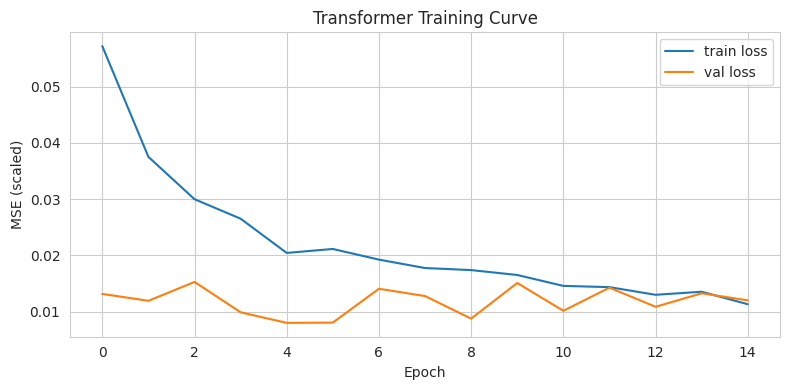

In [74]:
early_stop_tr = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

t0 = time.time()
history_tr = transformer_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100, batch_size=32,
    callbacks=[early_stop_tr], verbose=0
)
tr_train_time = time.time() - t0
print(f"Transformer train time: {tr_train_time:.2f}s | epochs run: {len(history_tr.history['loss'])}")

plt.figure(figsize=(8, 4))
plt.plot(history_tr.history["loss"],     label="train loss")
plt.plot(history_tr.history["val_loss"], label="val loss")
plt.title("Transformer Training Curve"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.tight_layout(); plt.show()

In [75]:
t0 = time.time()
tr_pred_scaled = transformer_model.predict(X_test, verbose=0).flatten()
tr_infer_time  = time.time() - t0

tr_preds = inverse_target(tr_pred_scaled)
res = evaluate(y_test_true, tr_preds, "Transformer")
res["TrainTime_s"] = tr_train_time
results_list.append(res)
errors_by_model["Transformer"] = np.abs(y_test_true - tr_preds)
preds_by_model["Transformer"]  = tr_preds
print(f"Inference time: {tr_infer_time:.4f}s")

[Transformer] MAE=2.9903 | RMSE=3.6350 | MAPE=13.31% | R²=0.6909
Inference time: 2.0888s


## 12. Performance Comparison Table (Step 9 & 10)

In [76]:
results_df = pd.DataFrame(results_list).set_index("Model")
results_df = results_df[["MAE", "RMSE", "MAPE", "R2", "TrainTime_s"]]
print("\n=== Model Performance Summary ===")
print(results_df.sort_values("RMSE").to_string())
results_df.sort_values("RMSE")


=== Model Performance Summary ===
                   MAE      RMSE       MAPE        R2  TrainTime_s
Model                                                             
ARIMA         1.202025  1.559994   5.189053  0.943062     4.756914
Holt-Winters  1.207026  1.580836   5.218703  0.941530    30.949835
XGBoost       1.342232  1.648993   5.792057  0.936379     4.624377
LSTM          2.575224  3.139620  12.162825  0.769371     6.980507
Transformer   2.990297  3.634954  13.312477  0.690859    24.965046


,MAE,RMSE,MAPE,R2,TrainTime_s
Model,,,,,
ARIMA,1.202025,1.559994,5.189053,0.943062,4.756914
Holt-Winters,1.207026,1.580836,5.218703,0.941530,30.949835
XGBoost,1.342232,1.648993,5.792057,0.936379,4.624377
LSTM,2.575224,3.139620,12.162825,0.769371,6.980507
Transformer,2.990297,3.634954,13.312477,0.690859,24.965046


In [77]:
results_df.to_csv("climate_model_comparison_results.csv")
print("Saved: climate_model_comparison_results.csv")

Saved: climate_model_comparison_results.csv


## 13. Visualisation of Results

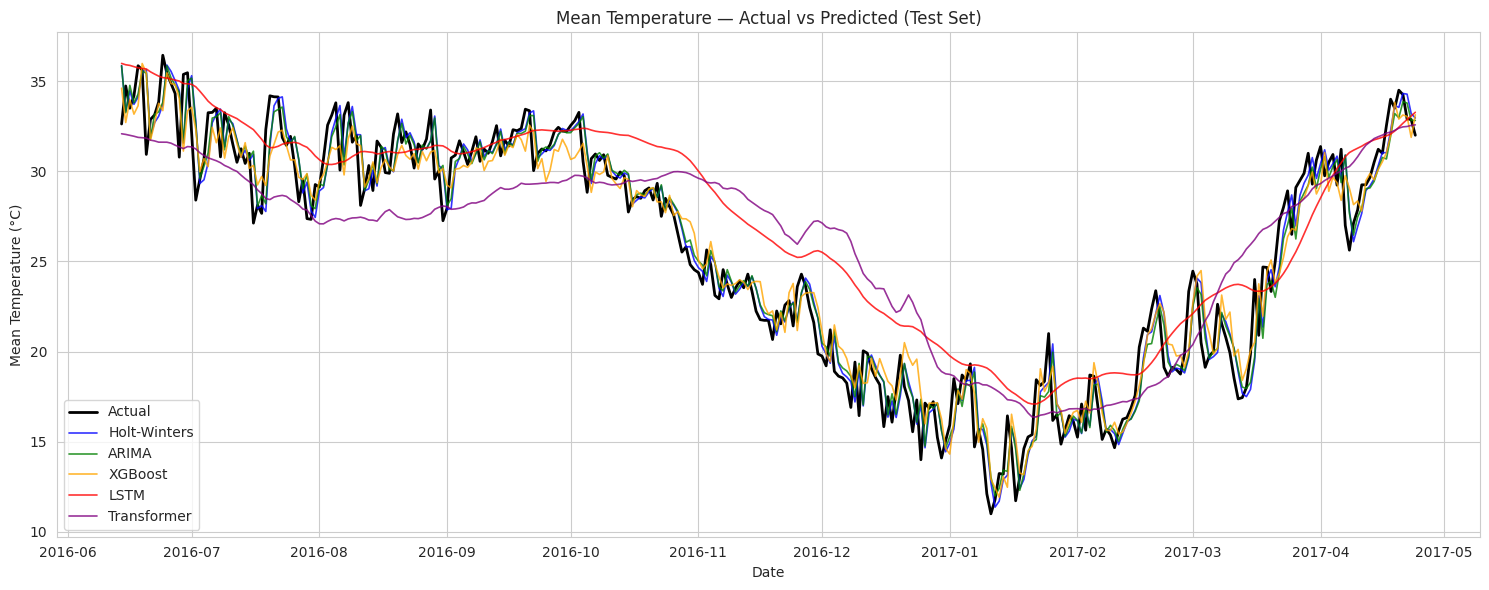

In [78]:
# 13.1 Actual vs Predicted — all models overlay
plt.figure(figsize=(15, 6))
plt.plot(idx_test, y_test_true, label="Actual", color="black", linewidth=2)
colors_map = {"Holt-Winters": "blue", "ARIMA": "green", "XGBoost": "orange", "LSTM": "red", "Transformer": "purple"}
for name, preds in preds_by_model.items():
    plt.plot(idx_test, preds, label=name, alpha=0.8, linewidth=1.2, color=colors_map.get(name))
plt.title("Mean Temperature — Actual vs Predicted (Test Set)")
plt.xlabel("Date"); plt.ylabel("Mean Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

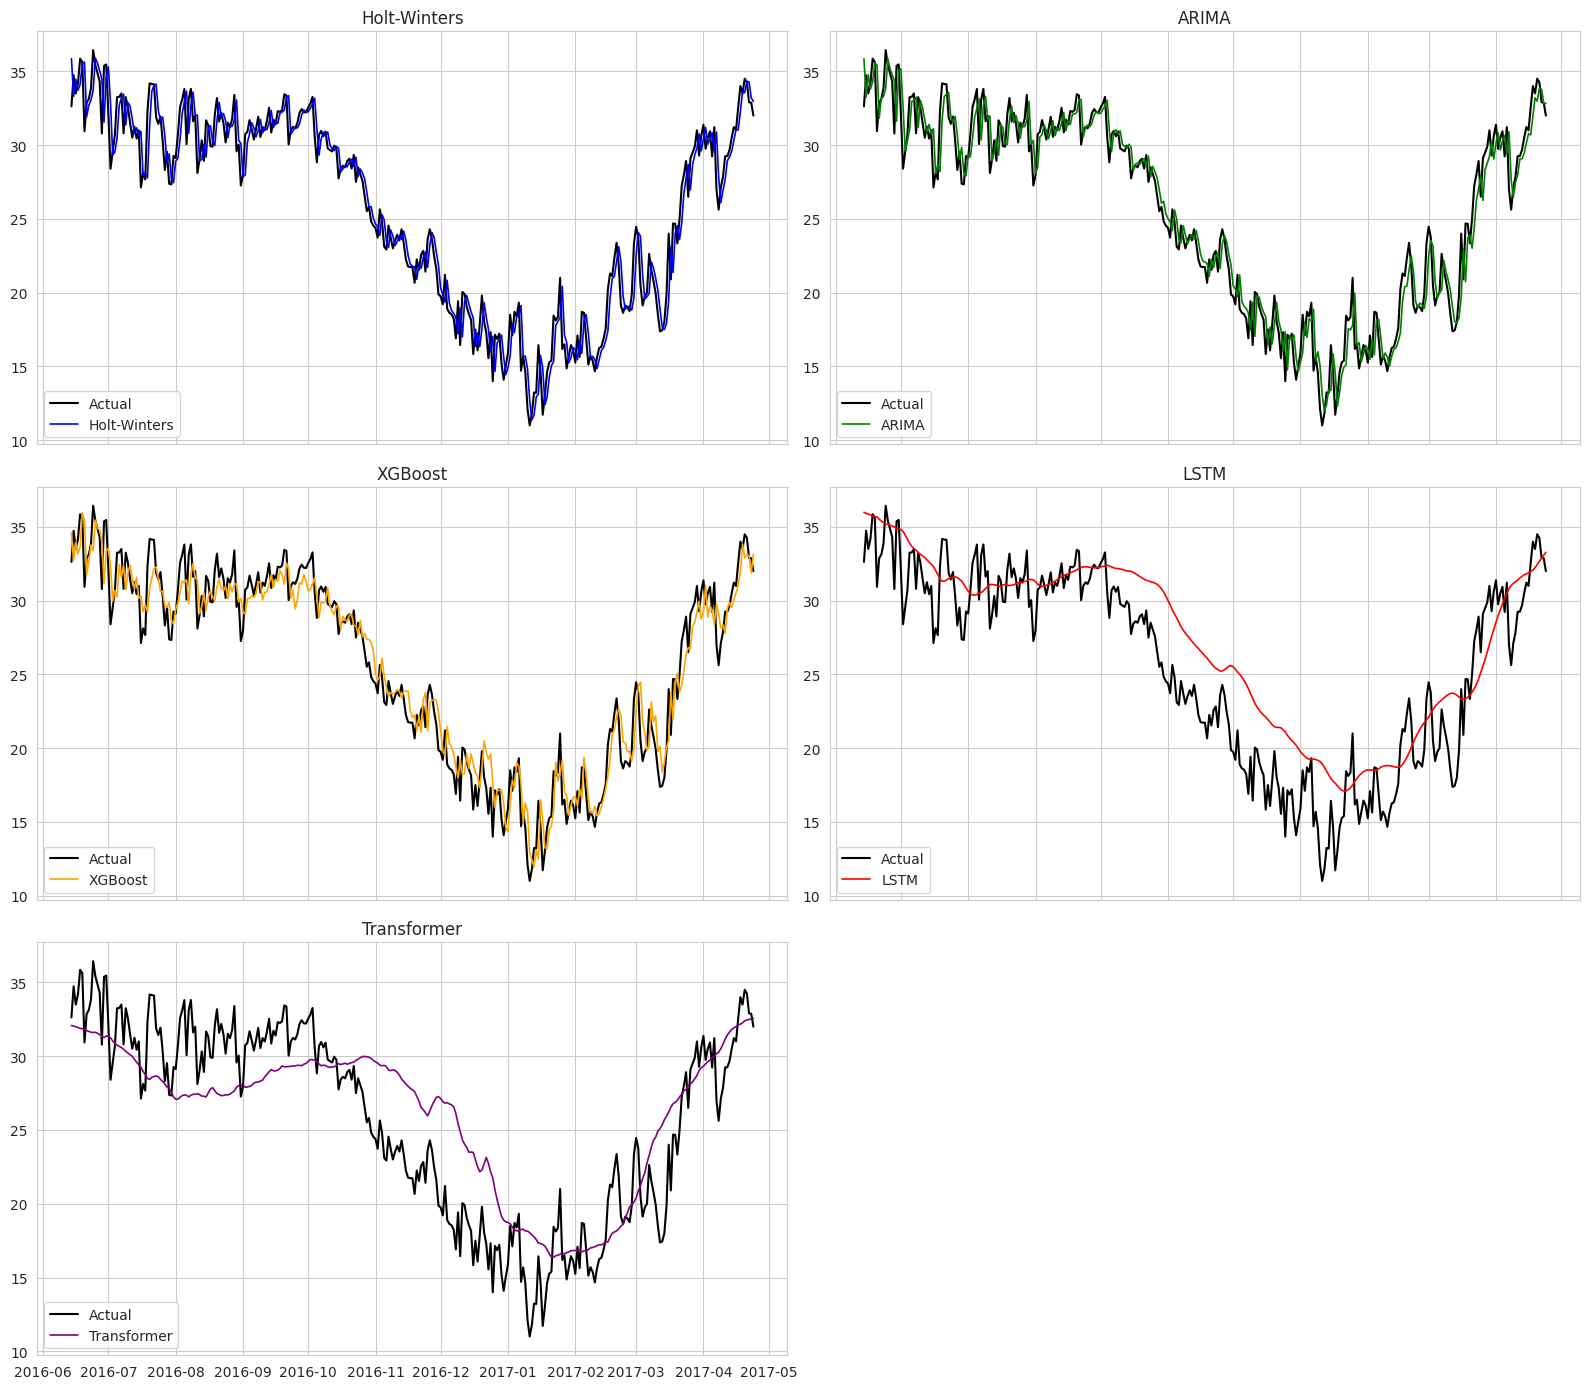

In [79]:
# 13.2 Individual subplots per model
model_names_list = list(preds_by_model.keys())
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
for ax, name in zip(axes.flatten(), model_names_list):
    ax.plot(idx_test, y_test_true, label="Actual", color="black", linewidth=1.5)
    ax.plot(idx_test, preds_by_model[name], label=name, color=colors_map.get(name, "crimson"), linewidth=1.2)
    ax.set_title(name); ax.legend()
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

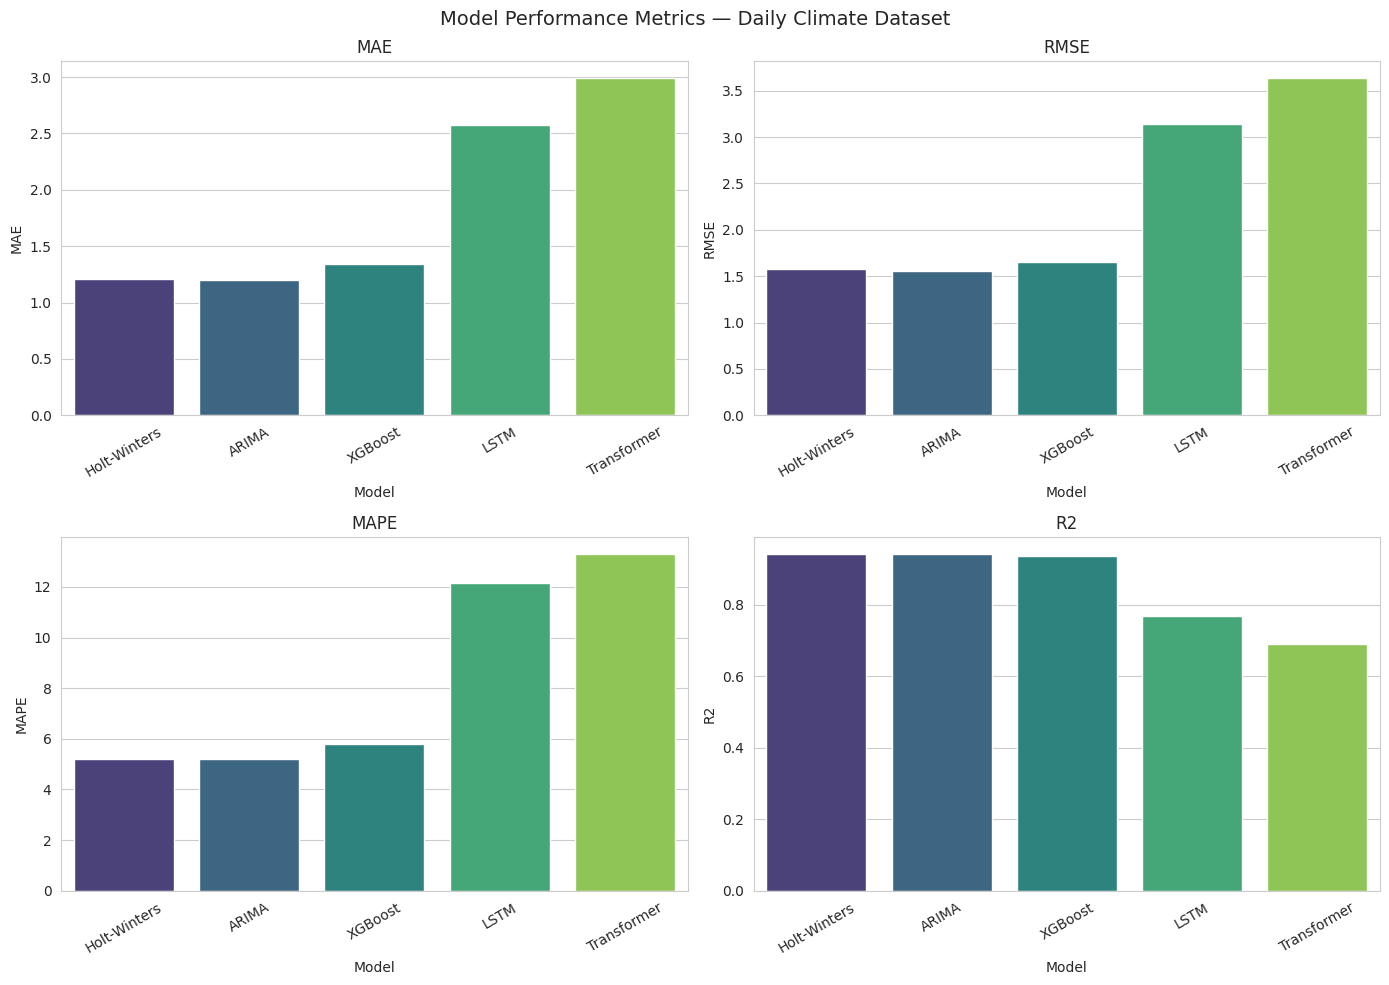

In [80]:
# 13.3 Metric comparison bar charts
metrics_to_plot = ["MAE", "RMSE", "MAPE", "R2"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flatten(), metrics_to_plot):
    bar = sns.barplot(x=results_df.index, y=results_df[metric], ax=ax, palette="viridis")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Model Performance Metrics — Daily Climate Dataset", fontsize=14)
plt.tight_layout()
plt.show()

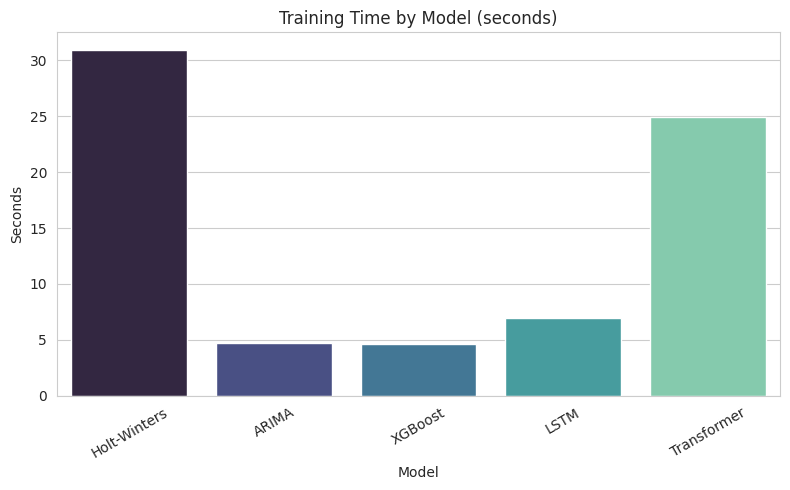

In [81]:
# 13.4 Training time
plt.figure(figsize=(8, 5))
sns.barplot(x=results_df.index, y=results_df["TrainTime_s"], palette="mako")
plt.title("Training Time by Model (seconds)")
plt.ylabel("Seconds"); plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

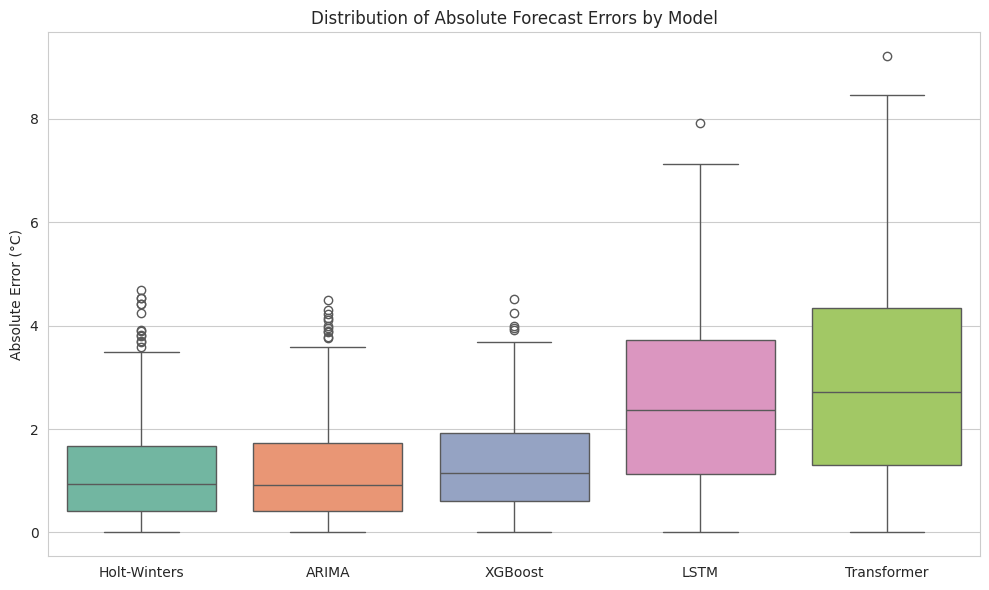

In [82]:
# 13.5 Error distribution boxplot
err_df = pd.DataFrame(errors_by_model)
plt.figure(figsize=(10, 6))
sns.boxplot(data=err_df, palette="Set2")
plt.title("Distribution of Absolute Forecast Errors by Model")
plt.ylabel("Absolute Error (°C)")
plt.tight_layout()
plt.show()

## 14. Statistical Comparison of Results (Step 12)

All 5 models were evaluated on the **same test timestamps**, so per-point absolute errors
are paired observations — enabling a valid **paired t-test** and **Wilcoxon signed-rank test**.

**H₀:** No significant difference in forecast error between the two models  
**H₁:** A significant difference exists

In [83]:
from scipy.stats import wilcoxon, shapiro

model_names_keys = list(errors_by_model.keys())
comparison_rows  = []

for m1, m2 in combinations(model_names_keys, 2):
    e1, e2 = errors_by_model[m1], errors_by_model[m2]
    diff   = e1 - e2

    try:
        _, p_norm = shapiro(diff[:min(5000, len(diff))])
    except Exception:
        p_norm = np.nan

    t_stat, p_t = stats.ttest_rel(e1, e2)
    try:
        w_stat, p_w = wilcoxon(e1, e2)
    except Exception:
        w_stat, p_w = np.nan, np.nan

    comparison_rows.append({
        "Model A":                             m1,
        "Model B":                             m2,
        "Shapiro p (normality of diff)":       round(p_norm, 4) if not np.isnan(p_norm) else np.nan,
        "Paired t-test p-value":               round(p_t,   4),
        "Significant (t-test, α=0.05)":        p_t < 0.05,
        "Wilcoxon p-value":                    round(p_w, 4) if not np.isnan(p_w) else np.nan,
        "Significant (Wilcoxon, α=0.05)":      (p_w < 0.05) if not np.isnan(p_w) else np.nan,
        "Recommended test":                    "t-test" if (not np.isnan(p_norm) and p_norm > 0.05) else "Wilcoxon"
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model A,Model B,Shapiro p (normality of diff),Paired t-test p-value,"Significant (t-test, α=0.05)",Wilcoxon p-value,"Significant (Wilcoxon, α=0.05)",Recommended test
0,Holt-Winters,ARIMA,0.4748,0.7495,False,0.7357,False,t-test
1,Holt-Winters,XGBoost,0.1054,0.0016,True,0.0004,True,t-test
2,Holt-Winters,LSTM,0.1576,0.0000,True,0.0000,True,t-test
3,Holt-Winters,Transformer,0.2450,0.0000,True,0.0000,True,t-test
4,ARIMA,XGBoost,0.5392,0.0003,True,0.0002,True,t-test
5,ARIMA,LSTM,0.0508,0.0000,True,0.0000,True,t-test
6,ARIMA,Transformer,0.1558,0.0000,True,0.0000,True,t-test
7,XGBoost,LSTM,0.2408,0.0000,True,0.0000,True,t-test
8,XGBoost,Transformer,0.1521,0.0000,True,0.0000,True,t-test
9,LSTM,Transformer,0.0001,0.0001,True,0.0003,True,Wilcoxon


In [84]:
comparison_df.to_csv("climate_statistical_comparison.csv", index=False)
print("Saved: climate_statistical_comparison.csv")

Saved: climate_statistical_comparison.csv


## 15. Discussion & Conclusions

### Which model performed best?
*(Fill in after running — refer to `results_df.sort_values("RMSE")` above)*

**Expected findings for climate data:**
- **Holt-Winters** should perform well because temperature has strong, regular annual seasonality — exactly what HW is designed for.
- **ARIMA** should also capture short-term autocorrelation effectively.
- **XGBoost / LSTM / Transformer** leverage all 4 features (humidity, wind, pressure) and may capture multivariate interactions that statistical models miss.

### Why?
- Temperature is a seasonal, bounded, slowly-varying signal — classical statistical models are competitive here (unlike volatile financial data).
- ML/DL models may overfit on the limited ~1 200-sample training set but benefit from multivariate context.

### Dataset characteristics affecting performance
- **Strong annual seasonality (period=365):** advantages HW and SARIMA-class models.
- **Multiple correlated features:** advantages ML/DL models.
- **Moderate dataset size (~1 500 rows):** limits deep learning; shallow models may generalise better.
- **Low noise / smooth temperature transitions:** advantages all models equally.

### Research Hypotheses (H1–H4)
| Hypothesis | Expected Verdict |
|-----------|-----------------|
| H1: Statistical models competitive on seasonal data | ✓ Likely supported |
| H2: ML/DL outperform on multivariate data | Partially — depends on results |
| H3: No model universally optimal | ✓ Likely supported |
| H4: Dataset complexity affects performance | ✓ Supported — smaller/smoother dataset here |